# Dataset Analysis, LLVIP

## Import dataset

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
!pip install imagehash

In [7]:
import os
import io
import zipfile
import random
import imagehash
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter, defaultdict
from matplotlib.patches import Patch

# zip_path = "/content/drive/MyDrive/4t/3r trimestre/Aprenentatge Profund/UPF_Deep_Learning_2026/Final Project/data/dataset_LLVIP/results_all_LLVIP.zip"
zip_path = "/content/drive/MyDrive/deep learning/UPF_Deep_Learning_2026/Final Project/data/dataset_LLVIP/results_all_LLVIP.zip"

BRIGHT_THRESHOLD = 200
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [8]:
# Find CSV and images dir automatically inside ZIP
with zipfile.ZipFile(zip_path, 'r') as z:
    all_files = z.namelist()
    csv_files = [f for f in all_files if f.endswith('dataset_labels.csv')]
    if not csv_files:
        raise FileNotFoundError("dataset_labels.csv not found inside ZIP.")
    INTERNAL_CSV_PATH   = csv_files[0]
    INTERNAL_IMAGES_DIR = os.path.join(
        os.path.dirname(os.path.dirname(INTERNAL_CSV_PATH)), "images"
    )
print(f"CSV: {INTERNAL_CSV_PATH}")
print(f"Images dir: {INTERNAL_IMAGES_DIR}")

CSV: results_all_LLVIP/labels/dataset_labels.csv
Images dir: results_all_LLVIP/images


In [9]:
with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open(INTERNAL_CSV_PATH) as f:
        df = pd.read_csv(f)

df.columns = ['filename', 'label']
print(df.head())
print(f"\nShape: {df.shape}")

     filename  label
0  010001.jpg      1
1  010002.jpg      1
2  010003.jpg      1
3  010004.jpg      1
4  010005.jpg      1

Shape: (43492, 2)


In [10]:
def load_all_stats(zip_path, internal_dir, filenames, labels=None):
    """Opens ZIP once and computes per-image stats: mean, std, max, bright_ratio."""
    results = []
    with zipfile.ZipFile(zip_path, 'r') as z:
        for i, fname in enumerate(filenames):
            img_path = os.path.join(internal_dir, fname)
            try:
                with z.open(img_path) as f:
                    pixels = np.array(Image.open(io.BytesIO(f.read())).convert('L')).flatten()
                results.append({
                    'filename'    : fname,
                    'label'       : labels[i] if labels is not None else None,
                    'mean'        : pixels.mean(),
                    'std'         : pixels.std(),
                    'max'         : pixels.max(),
                    'bright_ratio': (pixels > BRIGHT_THRESHOLD).sum() / len(pixels)
                })
            except Exception:
                pass
            if i % 2000 == 0:
                print(f"  {i}/{len(filenames)} processed...")
    return results

def load_images_from_zip(zip_path, internal_dir, filenames):
    """Opens ZIP once and returns list of grayscale PIL images."""
    imgs = []
    with zipfile.ZipFile(zip_path, 'r') as z:
        for fname in filenames:
            img_path = os.path.join(internal_dir, fname)
            with z.open(img_path) as f:
                imgs.append(Image.open(io.BytesIO(f.read())).convert('L'))
    return imgs

def show_problem_grid(df_subset, title, zip_path, internal_dir, n=8):
    subset = df_subset.head(n)
    if len(subset) == 0:
        print(f"No images found for: {title}")
        return
    cols = min(len(subset), 4)
    rows = (len(subset) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3))
    fig.suptitle(title, fontsize=12, fontweight='bold')
    axes = np.array(axes).flatten()
    imgs = load_images_from_zip(zip_path, internal_dir, subset['filename'].tolist())
    for ax, (_, row), img in zip(axes, subset.iterrows(), imgs):
        ax.imshow(img, cmap='gray', vmin=0, vmax=255)
        ax.set_title(f"mean={row['mean']:.1f} std={row['std']:.1f}", fontsize=8)
        ax.set_xlabel(f"label={int(row['label'])}", fontsize=8, color='gray')
        ax.set_xticks([]); ax.set_yticks([])
    for ax in axes[len(subset):]:
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(f"llvip_{title.replace(' ', '_')}.png", dpi=120, bbox_inches='tight')
    plt.show()

## Basic Statistics

In [11]:
total = len(df)
class_counts = df['label'].value_counts().sort_index()
class_names  = {0: 'No person', 1: 'Person'}

print("BASIC DATASET STATISTICS (LLVIP) \n")
print(f"\n Total images : {total}")
for label, count in class_counts.items():
    pct = 100 * count / total
    print(f"Class {label} ({class_names[label]}):  {count} images  ({pct:.1f}%)")

ratio = class_counts.max() / class_counts.min()
print(f"\n Class imbalance ratio : {ratio:.2f}x")
if ratio > 1.5:
    print("Class imbalance detected, consider class weighting or oversampling.")
else:
    print("Classes balanced.")

# Resolution distribution
print("\nRESOLUTION DISTRIBUTION")
resolutions = []
with zipfile.ZipFile(zip_path, 'r') as z:
    for fname in df['filename']:
        img_path = os.path.join(INTERNAL_IMAGES_DIR, fname)
        try:
            with z.open(img_path) as f:
                img = Image.open(io.BytesIO(f.read()))
                resolutions.append(img.size)
        except Exception:
            resolutions.append(None)
df['resolution'] = resolutions
res_counts = Counter(resolutions)
for res, count in sorted(r for r in res_counts.items() if r[0] is not None):
    print(f"  {res[0]}x{res[1]}  →  {count} images  ({100*count/total:.1f}%)")

# Dataset size
print("\n DATASET SIZE")
with zipfile.ZipFile(zip_path, 'r') as z:
    all_info    = z.infolist()
    image_files = [f for f in all_info if f.filename.startswith(INTERNAL_IMAGES_DIR)
                   and not f.filename.endswith('/')]
    total_bytes = sum(f.file_size    for f in image_files)
    zip_bytes   = sum(f.compress_size for f in image_files)
print(f"\n Uncompressed size : {total_bytes / 1e6:.1f} MB")
print(f"  Size in ZIP      : {zip_bytes   / 1e6:.1f} MB")
print(f"  Compression ratio: {total_bytes / zip_bytes:.2f}x")

BASIC DATASET STATISTICS (LLVIP) 


 Total images : 43492
Class 0 (No person):  18257 images  (42.0%)
Class 1 (Person):  25235 images  (58.0%)

 Class imbalance ratio : 1.38x
Classes balanced.

RESOLUTION DISTRIBUTION
  640x512  →  28004 images  (64.4%)
  1280x1024  →  15488 images  (35.6%)

 DATASET SIZE

 Uncompressed size : 3728.5 MB
  Size in ZIP      : 3426.2 MB
  Compression ratio: 1.09x


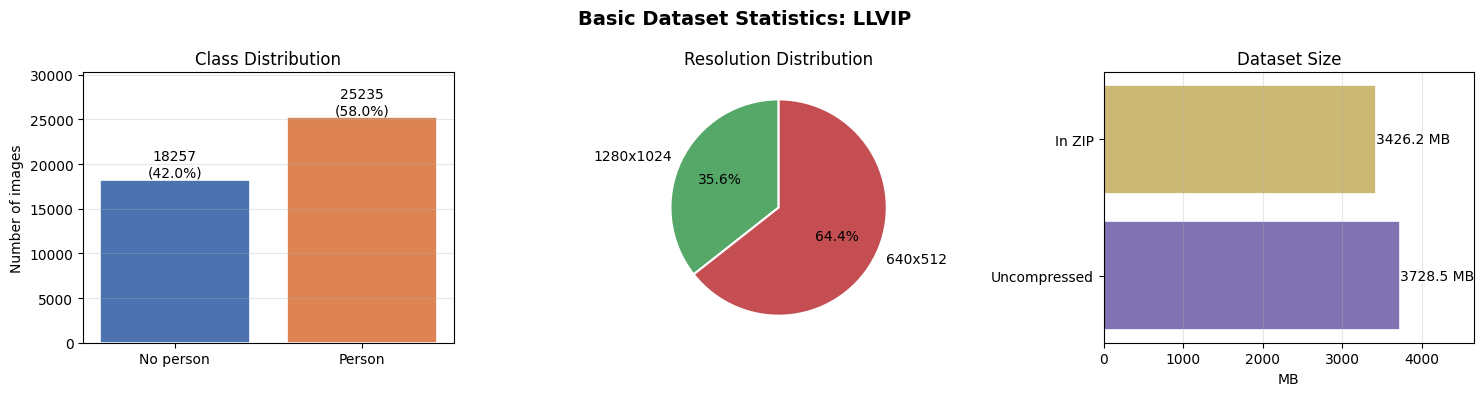

In [12]:
# PLOTS
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Basic Dataset Statistics: LLVIP", fontsize=14, fontweight='bold')

colors = ['#4C72B0', '#DD8452']
bars = axes[0].bar([class_names[l] for l in class_counts.index], class_counts.values,
                    color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Number of images")
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val}\n({100*val/total:.1f}%)', ha='center', va='bottom', fontsize=10)
axes[0].set_ylim(0, class_counts.max() * 1.2)
axes[0].grid(axis='y', alpha=0.3)

valid_res = {f"{k[0]}x{k[1]}": v for k, v in res_counts.items() if k is not None}
axes[1].pie(valid_res.values(), labels=valid_res.keys(), autopct='%1.1f%%',
            colors=['#55A868', '#C44E52'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title("Resolution Distribution")

sizes_mb  = [total_bytes / 1e6, zip_bytes / 1e6]
labels_mb = ['Uncompressed', 'In ZIP']
hbars = axes[2].barh(labels_mb, sizes_mb, color=['#8172B3', '#CCB974'],
                      edgecolor='white', linewidth=1.2)
axes[2].set_title("Dataset Size")
axes[2].set_xlabel("MB")
for bar, val in zip(hbars, sizes_mb):
    axes[2].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f} MB', va='center', fontsize=10)
axes[2].set_xlim(0, max(sizes_mb) * 1.25)
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Compute Per-Image Stats

This cell computes mean, std, max and bright_ratio for every image.
Results are stored in `df_stats` and reused in all following sections.

In [13]:
print("Computing per-image stats (one ZIP pass)...")
all_filenames = df['filename'].tolist()
all_labels    = df['label'].tolist()

stats   = load_all_stats(zip_path, INTERNAL_IMAGES_DIR, all_filenames, all_labels)
df_stats = pd.DataFrame(stats)
print(f"Done. {len(df_stats)} images processed.")
print(df_stats.describe())

Computing per-image stats (one ZIP pass)...
  0/43492 processed...
  2000/43492 processed...
  4000/43492 processed...
  6000/43492 processed...
  8000/43492 processed...
  10000/43492 processed...
  12000/43492 processed...
  14000/43492 processed...
  16000/43492 processed...
  18000/43492 processed...
  20000/43492 processed...
  22000/43492 processed...
  24000/43492 processed...
  26000/43492 processed...
  28000/43492 processed...
  30000/43492 processed...
  32000/43492 processed...
  34000/43492 processed...
  36000/43492 processed...
  38000/43492 processed...
  40000/43492 processed...
  42000/43492 processed...
Done. 43492 images processed.
              label          mean           std           max  bright_ratio
count  43492.000000  43492.000000  43492.000000  43492.000000  43492.000000
mean       0.580222     75.690331     41.814538    227.079394      0.014327
std        0.493528     22.004229      9.186911     29.320288      0.021087
min        0.000000      2.352103   

## Visual Analysis

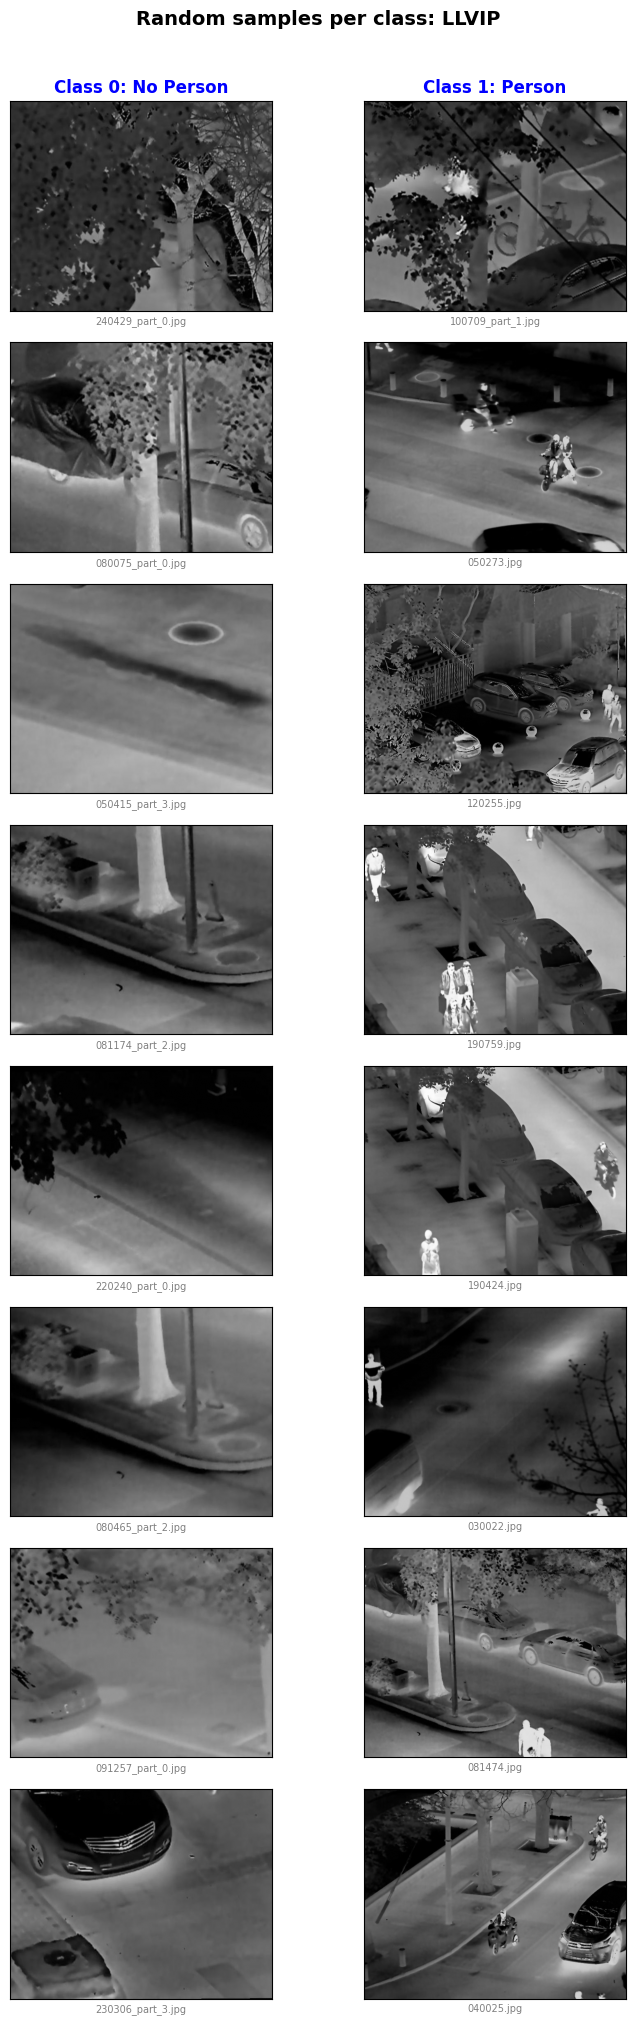

In [14]:
# Grid of random samples per class
N_SAMPLES = 8
samples_0 = df[df['label'] == 0]['filename'].sample(N_SAMPLES, random_state=SEED).tolist()
samples_1 = df[df['label'] == 1]['filename'].sample(N_SAMPLES, random_state=SEED).tolist()

imgs_0 = load_images_from_zip(zip_path, INTERNAL_IMAGES_DIR, samples_0)
imgs_1 = load_images_from_zip(zip_path, INTERNAL_IMAGES_DIR, samples_1)

fig, axes = plt.subplots(N_SAMPLES, 2, figsize=(8, N_SAMPLES * 2.5))
fig.suptitle("Random samples per class: LLVIP", fontsize=14, fontweight='bold', y=1.01)

col_titles = ['Class 0: No Person', 'Class 1: Person']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=12, fontweight='bold', color='blue')
for i, (img0, img1, f0, f1) in enumerate(zip(imgs_0, imgs_1, samples_0, samples_1)):
    for ax, img, fname in zip(axes[i], [img0, img1], [f0, f1]):
        ax.imshow(img, cmap='gray', vmin=0, vmax=255)
        ax.set_xlabel(fname, fontsize=7, color='gray')
        ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

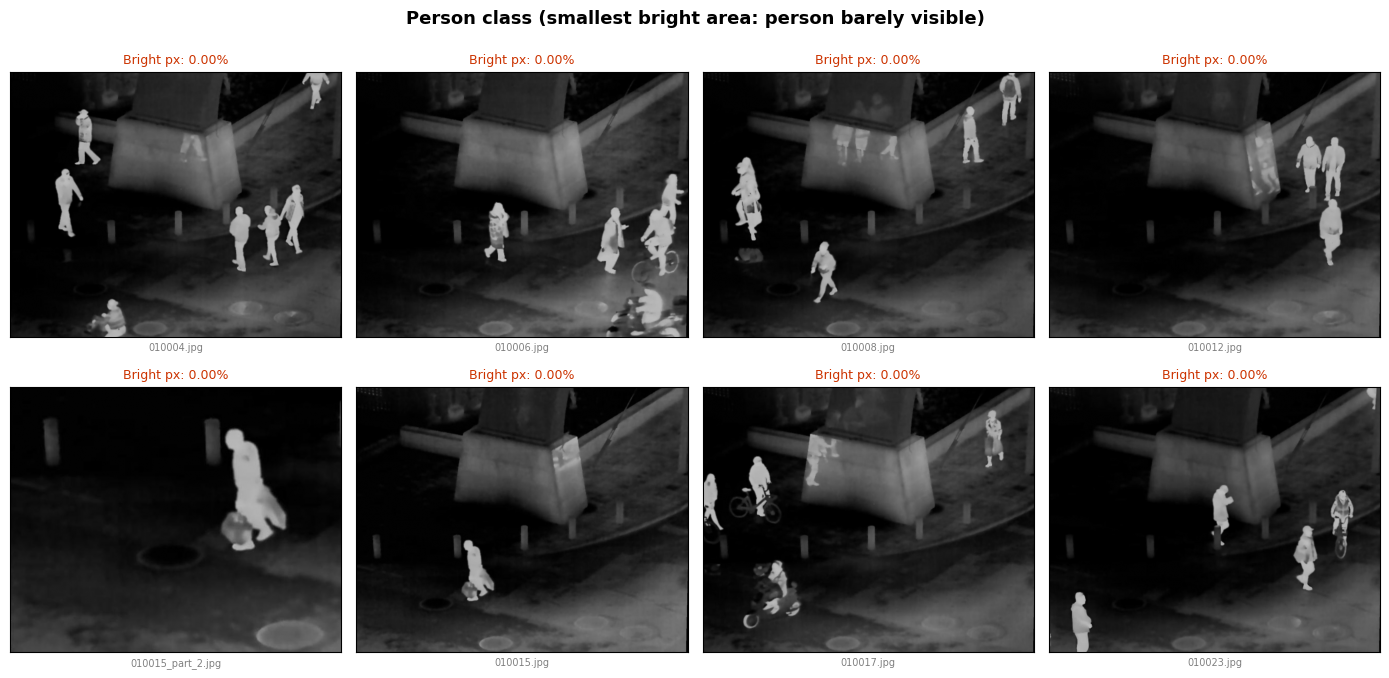

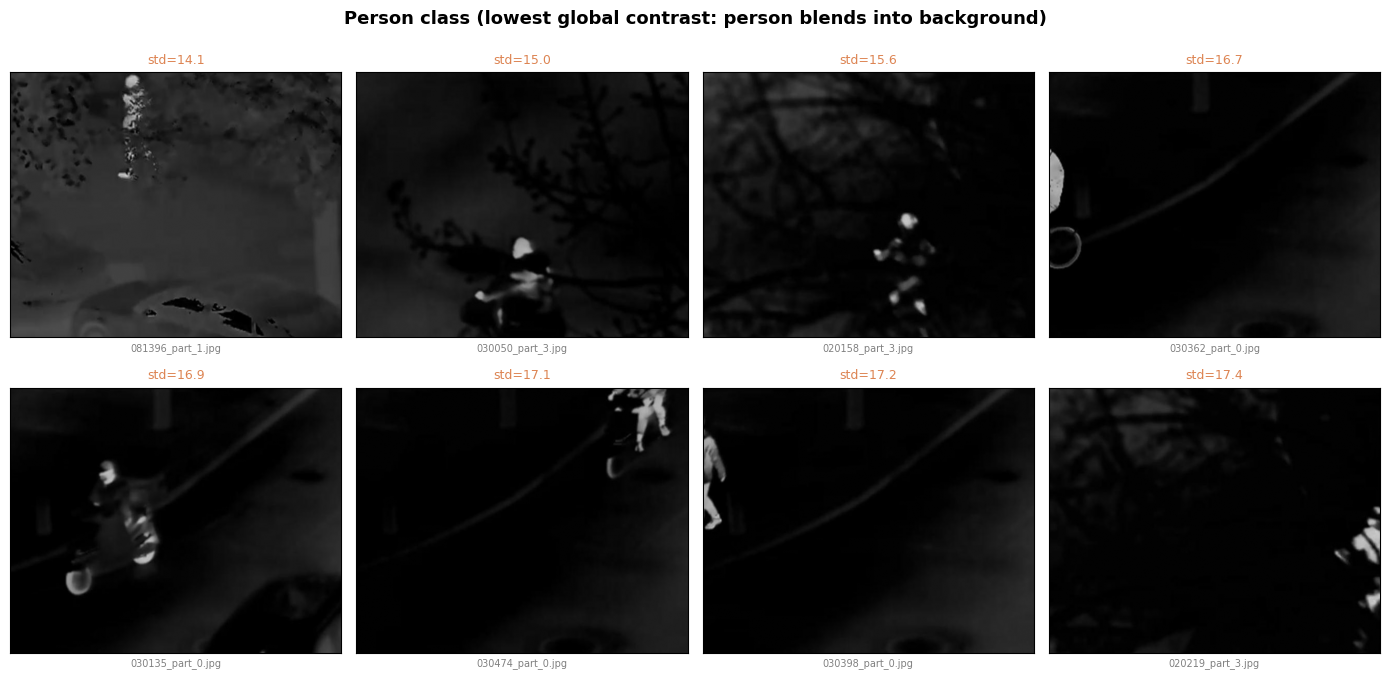

In [15]:
# Hardest images: small person and low contrast with class 1 only
N_HARD = 8

# smallest bright area
hardest_A     = df_stats[df_stats['label'] == 1].nsmallest(N_HARD, 'bright_ratio')
imgs_A        = load_images_from_zip(zip_path, INTERNAL_IMAGES_DIR, hardest_A['filename'].tolist())

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Person class (smallest bright area: person barely visible)",
             fontsize=13, fontweight='bold')
for ax, row, img in zip(axes.flatten(), hardest_A.itertuples(), imgs_A):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f"Bright px: {row.bright_ratio*100:.2f}%", fontsize=9, color='#CC3300')
    ax.set_xlabel(row.filename, fontsize=7, color='gray')
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

# lowest global contrast
hardest_B     = df_stats[df_stats['label'] == 1].nsmallest(N_HARD, 'std')
imgs_B        = load_images_from_zip(zip_path, INTERNAL_IMAGES_DIR, hardest_B['filename'].tolist())

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Person class (lowest global contrast: person blends into background)",
             fontsize=13, fontweight='bold')
for ax, row, img in zip(axes.flatten(), hardest_B.itertuples(), imgs_B):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f"std={row.std:.1f}", fontsize=9, color='#DD8452')
    ax.set_xlabel(row.filename, fontsize=7, color='gray')
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

Loading pixels for histogram...
Done. Class 0: 65,536,000 px  |  Class 1: 186,449,920 px

  Mean: Class 0: 72.92  |  Class 1: 76.75
  Difference of means   : 3.83
  Separability index d' : 0.082
  Low separability.


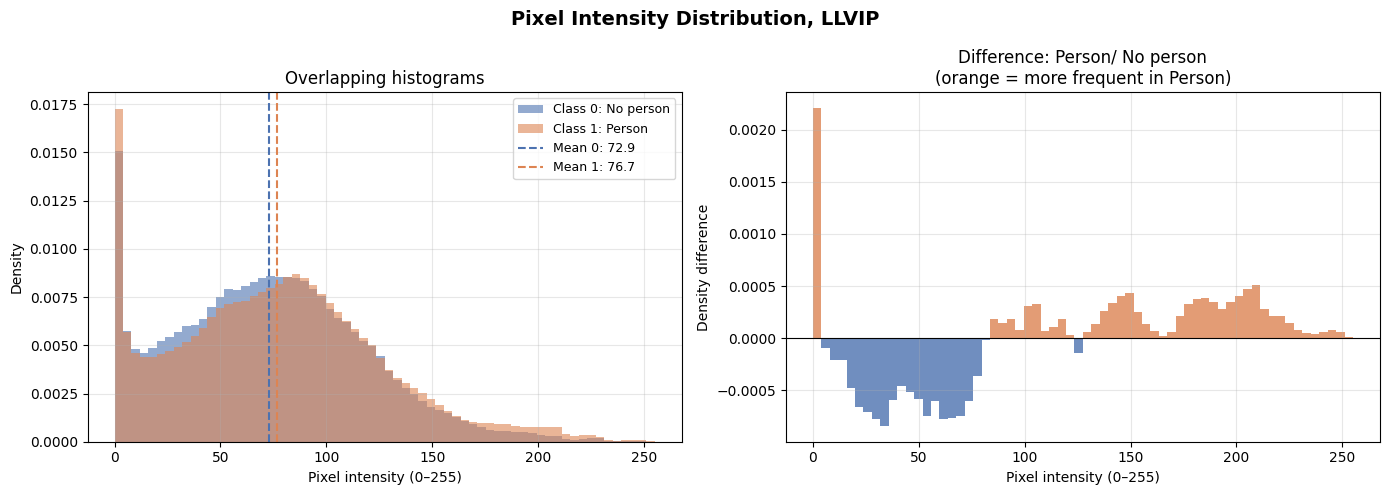

In [16]:
# Pixel intensity histogram per class
# Using sample of 200 per class (33k images too slow/memory to load all)
N_SAMPLE_HIST = 200

sample_0 = df_stats[df_stats['label'] == 0].sample(N_SAMPLE_HIST, random_state=SEED)['filename'].tolist()
sample_1 = df_stats[df_stats['label'] == 1].sample(N_SAMPLE_HIST, random_state=SEED)['filename'].tolist()
# #try all fotos
# sample_0 = df_stats[df_stats['label'] == 0]['filename'].tolist()
# sample_1 = df_stats[df_stats['label'] == 1]['filename'].tolist()

print("Loading pixels for histogram...")
with zipfile.ZipFile(zip_path, 'r') as z:
    pixels_0 = np.concatenate([
        np.array(Image.open(io.BytesIO(z.open(os.path.join(INTERNAL_IMAGES_DIR, f)).read())).convert('L')).flatten()
        for f in sample_0
    ])
    pixels_1 = np.concatenate([
        np.array(Image.open(io.BytesIO(z.open(os.path.join(INTERNAL_IMAGES_DIR, f)).read())).convert('L')).flatten()
        for f in sample_1
    ])
print(f"Done. Class 0: {len(pixels_0):,} px  |  Class 1: {len(pixels_1):,} px")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Pixel Intensity Distribution, LLVIP", fontsize=14, fontweight='bold')
BINS = 64

mean_0, mean_1 = pixels_0.mean(), pixels_1.mean()
axes[0].hist(pixels_0, bins=BINS, range=(0,255), density=True,
             alpha=0.6, color='#4C72B0', label='Class 0: No person')
axes[0].hist(pixels_1, bins=BINS, range=(0,255), density=True,
             alpha=0.6, color='#DD8452', label='Class 1: Person')
axes[0].axvline(mean_0, color='#4C72B0', linestyle='--', linewidth=1.5, label=f'Mean 0: {mean_0:.1f}')
axes[0].axvline(mean_1, color='#DD8452', linestyle='--', linewidth=1.5, label=f'Mean 1: {mean_1:.1f}')
axes[0].set_xlabel("Pixel intensity (0–255)")
axes[0].set_ylabel("Density")
axes[0].set_title("Overlapping histograms")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

hist_0, edges = np.histogram(pixels_0, bins=BINS, range=(0,255), density=True)
hist_1, _     = np.histogram(pixels_1, bins=BINS, range=(0,255), density=True)
centers = (edges[:-1] + edges[1:]) / 2
diff = hist_1 - hist_0
axes[1].bar(centers, diff, width=(255/BINS),
            color=np.where(diff >= 0, '#DD8452', '#4C72B0'), alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel("Pixel intensity (0–255)")
axes[1].set_ylabel("Density difference")
axes[1].set_title("Difference: Person/ No person\n(orange = more frequent in Person)")
axes[1].grid(alpha=0.3)

separability = abs(mean_1 - mean_0) / ((pixels_0.std() + pixels_1.std()) / 2)
print(f"\n  Mean: Class 0: {mean_0:.2f}  |  Class 1: {mean_1:.2f}")
print(f"  Difference of means   : {abs(mean_1 - mean_0):.2f}")
print(f"  Separability index d' : {separability:.3f}")
print(" Meaningful separation." if separability > 0.5 else "  Low separability.")

plt.tight_layout()
plt.show()

## Intensity Analysis

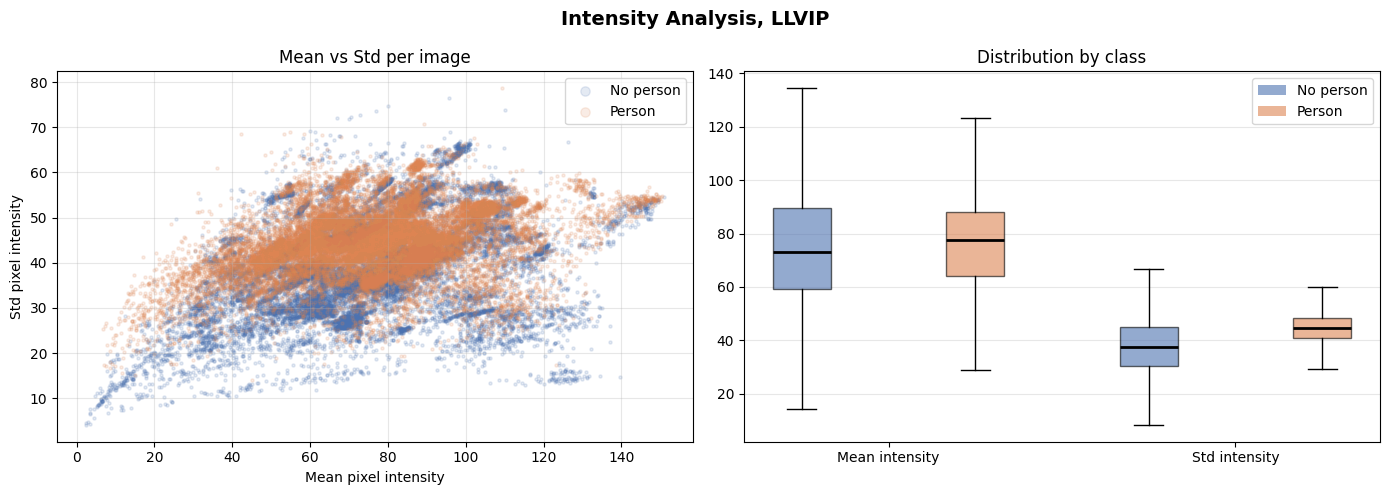

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Intensity Analysis, LLVIP", fontsize=14, fontweight='bold')

colors_map = {0: '#4C72B0', 1: '#DD8452'}
labels_map = {0: 'No person', 1: 'Person'}

# Scatter mean vs std
for label in [0, 1]:
    subset = df_stats[df_stats['label'] == label]
    axes[0].scatter(subset['mean'], subset['std'],
                    alpha=0.15, s=5, color=colors_map[label], label=labels_map[label])
axes[0].set_xlabel("Mean pixel intensity")
axes[0].set_ylabel("Std pixel intensity")
axes[0].set_title("Mean vs Std per image")
axes[0].legend(fontsize=10, markerscale=3)
axes[0].grid(alpha=0.3)

# Boxplots
data_mean = [df_stats[df_stats['label']==0]['mean'].values,
             df_stats[df_stats['label']==1]['mean'].values]
data_std  = [df_stats[df_stats['label']==0]['std'].values,
             df_stats[df_stats['label']==1]['std'].values]

bp1 = axes[1].boxplot(data_mean, positions=[1, 2.5], widths=0.5,
                      patch_artist=True, showfliers=False,
                      medianprops=dict(color='black', linewidth=2))
bp1['boxes'][0].set_facecolor('#4C72B0'); bp1['boxes'][0].set_alpha(0.6)
bp1['boxes'][1].set_facecolor('#DD8452'); bp1['boxes'][1].set_alpha(0.6)

bp2 = axes[1].boxplot(data_std, positions=[4, 5.5], widths=0.5,
                      patch_artist=True, showfliers=False,
                      medianprops=dict(color='black', linewidth=2))
bp2['boxes'][0].set_facecolor('#4C72B0'); bp2['boxes'][0].set_alpha(0.6)
bp2['boxes'][1].set_facecolor('#DD8452'); bp2['boxes'][1].set_alpha(0.6)

axes[1].set_xticks([1.75, 4.75])
axes[1].set_xticklabels(['Mean intensity', 'Std intensity'])
axes[1].set_title("Distribution by class")
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend(handles=[Patch(facecolor='#4C72B0', alpha=0.6, label='No person'),
                         Patch(facecolor='#DD8452', alpha=0.6, label='Person')], fontsize=10)

plt.tight_layout()
plt.show()

Computing average images (one ZIP pass)...
Done. Class 0: 18257 images  |  Class 1: 25235 images


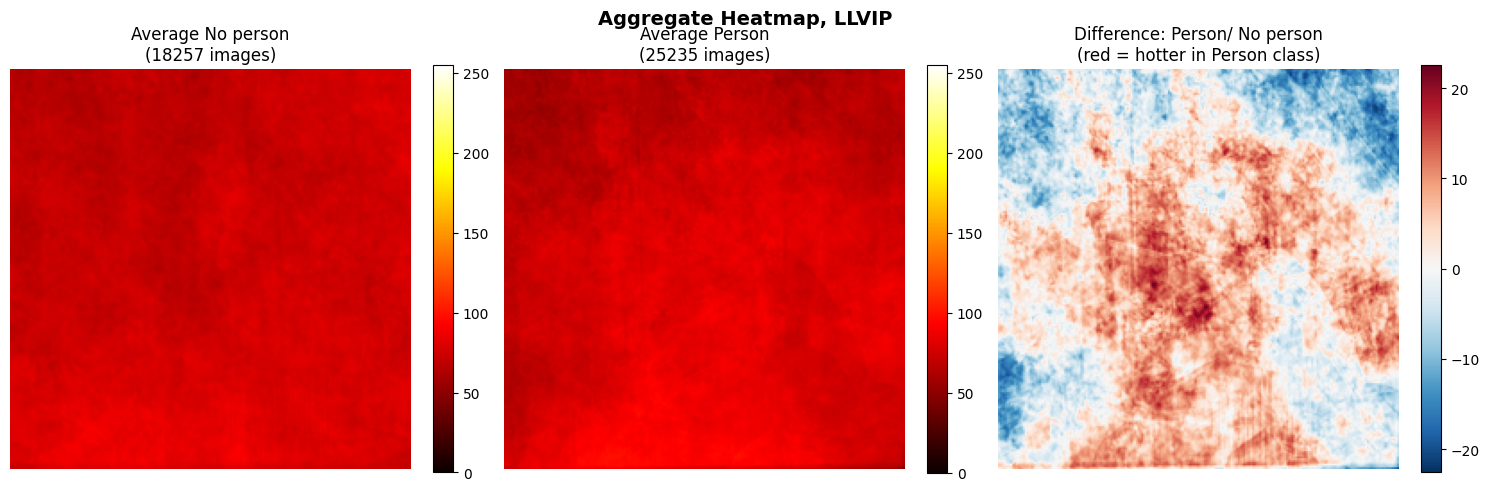

In [18]:
# Aggregate heatmap per class
TARGET_SIZE = (224, 224)
acc_0 = np.zeros(TARGET_SIZE, dtype=np.float64)
acc_1 = np.zeros(TARGET_SIZE, dtype=np.float64)
count_0, count_1 = 0, 0

print("Computing average images (one ZIP pass)...")
with zipfile.ZipFile(zip_path, 'r') as z:
    for _, row in df.iterrows():
        img_path = os.path.join(INTERNAL_IMAGES_DIR, row['filename'])
        try:
            with z.open(img_path) as f:
                img = np.array(
                    Image.open(io.BytesIO(f.read())).convert('L').resize(TARGET_SIZE),
                    dtype=np.float64)
            if row['label'] == 0:
                acc_0 += img; count_0 += 1
            else:
                acc_1 += img; count_1 += 1
        except Exception:
            pass

avg_0 = acc_0 / count_0
avg_1 = acc_1 / count_1
diff  = avg_1 - avg_0
print(f"Done. Class 0: {count_0} images  |  Class 1: {count_1} images")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Aggregate Heatmap, LLVIP", fontsize=14, fontweight='bold')

im0 = axes[0].imshow(avg_0, cmap='hot', vmin=0, vmax=255)
axes[0].set_title(f"Average No person\n({count_0} images)")
axes[0].axis('off'); plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(avg_1, cmap='hot', vmin=0, vmax=255)
axes[1].set_title(f"Average Person\n({count_1} images)")
axes[1].axis('off'); plt.colorbar(im1, ax=axes[1], fraction=0.046)

vmax = np.abs(diff).max()
imd = axes[2].imshow(diff, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[2].set_title("Difference: Person/ No person\n(red = hotter in Person class)")
axes[2].axis('off'); plt.colorbar(imd, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

## Problem Detection

In [19]:
# Corrupt / empty images
BLACK_MAX_THRESH  = 5
WHITE_MEAN_THRESH = 250
LOW_STD_THRESH    = 2

black = df_stats[df_stats['max']  < BLACK_MAX_THRESH]
white = df_stats[df_stats['mean'] > WHITE_MEAN_THRESH]
flat  = df_stats[(df_stats['std'] < LOW_STD_THRESH) &
                 (df_stats['max'] >= BLACK_MAX_THRESH) &
                 (df_stats['mean'] <= WHITE_MEAN_THRESH)]

print("CORRUPT / PROBLEMATIC IMAGES")
print(f"Totally black: {len(black)} images")
print(f"Totally white: {len(white)} images")
print(f"Near-flat: {len(flat)} images")
print(f"Total affected: {len(black)+len(white)+len(flat)} ({100*(len(black)+len(white)+len(flat))/len(df_stats):.2f}%)")

CORRUPT / PROBLEMATIC IMAGES
Totally black: 0 images
Totally white: 0 images
Near-flat: 0 images
Total affected: 0 (0.00%)


In [20]:
# Perceptual hashing, near-duplicate detection
HASH_SIZE    = 8
MAX_DISTANCE = 5

print("Computing perceptual hashes (one ZIP pass)...")
hashes = {}
with zipfile.ZipFile(zip_path, 'r') as z:
    for i, fname in enumerate(df['filename'].tolist()):
        img_path = os.path.join(INTERNAL_IMAGES_DIR, fname)
        try:
            with z.open(img_path) as f:
                img = Image.open(io.BytesIO(f.read())).convert('L')
                hashes[fname] = imagehash.phash(img, hash_size=HASH_SIZE)
        except Exception:
            pass
        if i % 5000 == 0:
            print(f"  {i}/{len(df)} hashed...")
print(f"Done. {len(hashes)} hashes computed.")

# Group near-duplicates via Union-Find (fast, avoids O(n²))
print("\nGrouping near-duplicates...")

parent = {f: f for f in hashes}

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(x, y):
    parent[find(x)] = find(y)

bit_buckets = defaultdict(list)
for fname, h in hashes.items():
    for bit_idx, bit in enumerate(bin(int(str(h), 16))[2:].zfill(64)):
        if bit == '1':
            bit_buckets[(bit_idx, '1')].append(fname)

compared = set()
for bucket in bit_buckets.values():
    if len(bucket) < 2 or len(bucket) > 500:
        continue
    for i in range(len(bucket)):
        for j in range(i+1, len(bucket)):
            pair = (min(bucket[i], bucket[j]), max(bucket[i], bucket[j]))
            if pair in compared:
                continue
            compared.add(pair)
            if (hashes[bucket[i]] - hashes[bucket[j]]) <= MAX_DISTANCE:
                union(bucket[i], bucket[j])

groups_dict = defaultdict(list)
for fname in hashes:
    groups_dict[find(fname)].append(fname)

dup_groups = [g for g in groups_dict.values() if len(g) > 1]
total_dup_images = sum(len(g) for g in dup_groups)

print(f"\nDuplicate groups found: {len(dup_groups)}")
print(f"Images affected: {total_dup_images} ({100*total_dup_images/len(df):.1f}%)")
print(f"Largest group size: {max((len(g) for g in dup_groups), default=0)}")

Computing perceptual hashes (one ZIP pass)...
  0/43492 hashed...
  5000/43492 hashed...
  10000/43492 hashed...
  15000/43492 hashed...
  20000/43492 hashed...
  25000/43492 hashed...
  30000/43492 hashed...
  35000/43492 hashed...
  40000/43492 hashed...
Done. 43492 hashes computed.

Grouping near-duplicates...

Duplicate groups found: 0
Images affected: 0 (0.0%)
Largest group size: 0


In [21]:
# Show top duplicate groups
top_groups = sorted(dup_groups, key=len, reverse=True)[:5]

if top_groups:
    n_rows = len(top_groups)
    fig, axes = plt.subplots(n_rows, 4, figsize=(14, n_rows * 3))
    if n_rows == 1:
        axes = axes[np.newaxis, :]
    fig.suptitle("Top duplicate groups, LLVIP", fontsize=13, fontweight='bold')

    for row_i, group in enumerate(top_groups):
        samples = group[:4]
        imgs    = load_images_from_zip(zip_path, INTERNAL_IMAGES_DIR, samples)
        for col_i, (fname, img) in enumerate(zip(samples, imgs)):
            ax = axes[row_i][col_i]
            ax.imshow(img, cmap='gray', vmin=0, vmax=255)
            label = df[df['filename'] == fname]['label'].values[0]
            ax.set_title(f"label={label}", fontsize=8, color='#CC3300')
            ax.set_xlabel(fname, fontsize=6, color='gray')
            ax.set_xticks([]); ax.set_yticks([])
        for col_i in range(len(samples), 4):
            axes[row_i][col_i].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No duplicate groups to display.")

# Dubious labels
dubious = df_stats[
    (df_stats['label'] == 1) &
    (df_stats['bright_ratio'] < 0.005) &
    (df_stats['std'] < 15.0)
]
print(f"\nDubious labels (class 1, barely detectable): {len(dubious)}")

No duplicate groups to display.

Dubious labels (class 1, barely detectable): 1
